In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

All libraries imported successfully!
Pandas: 2.2.2
NumPy: 2.0.2


In [2]:
# Cell 2 — Load Dataset
df = pd.read_csv('cars_data_clean.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (37813, 66)

Columns: ['usedCarSkuId', 'loc', 'myear', 'body', 'transmission', 'fuel', 'km', 'ip', 'images', 'imgCount', 'threesixty', 'dvn', 'oem', 'model', 'variant', 'City', 'listed_price', 'discountValue', 'utype', 'carType', 'top_features', 'comfort_features', 'interior_features', 'exterior_features', 'safety_features', 'Color', 'Engine Type', 'No of Cylinder', 'Valves per Cylinder', 'Valve Configuration', 'Turbo Charger', 'Super Charger', 'Length', 'Width', 'Height', 'Wheel Base', 'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight', 'Gear Box', 'Drive Type', 'Seats', 'Steering Type', 'Turning Radius', 'Front Brake Type', 'Rear Brake Type', 'Top Speed', 'Acceleration', 'Tyre Type', 'Doors', 'Cargo Volume', 'model_type_new', 'state', 'exterior_color', 'owner_type', 'Fuel Suppy System', 'Compression Ratio', 'Alloy Wheel Size', 'Ground Clearance Unladen', 'Max Power Delivered', 'Max Power At', 'Max Torque Delivered', 'Max Torque At', 'Bore', 'Stroke']


In [3]:
# Cell 3 — Drop Irrelevant Columns
drop_cols = [
    'usedCarSkuId',   # just an ID
    'images',         # image URLs
    'imgCount',       # count of images
    'threesixty',     # 360 image flag
    'dvn',            # internal code
    'ip',             # internal field
    'discountValue',  # not a feature for price prediction
    'utype',          # internal type
    'carType',        # redundant with body
    'top_features',   # raw text, too messy
    'comfort_features',
    'interior_features',
    'exterior_features',
    'safety_features',
    'model_type_new', # redundant with model/variant
    'loc',            # redundant with City/state
]

df.drop(columns=drop_cols, inplace=True)

print("Shape after dropping:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping: (37813, 50)
Remaining columns: ['myear', 'body', 'transmission', 'fuel', 'km', 'oem', 'model', 'variant', 'City', 'listed_price', 'Color', 'Engine Type', 'No of Cylinder', 'Valves per Cylinder', 'Valve Configuration', 'Turbo Charger', 'Super Charger', 'Length', 'Width', 'Height', 'Wheel Base', 'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight', 'Gear Box', 'Drive Type', 'Seats', 'Steering Type', 'Turning Radius', 'Front Brake Type', 'Rear Brake Type', 'Top Speed', 'Acceleration', 'Tyre Type', 'Doors', 'Cargo Volume', 'state', 'exterior_color', 'owner_type', 'Fuel Suppy System', 'Compression Ratio', 'Alloy Wheel Size', 'Ground Clearance Unladen', 'Max Power Delivered', 'Max Power At', 'Max Torque Delivered', 'Max Torque At', 'Bore', 'Stroke']


In [4]:
# Cell 4 — Null Analysis & Data Types
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
null_df = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2)
})
null_df = null_df[null_df['Null Count'] > 0].sort_values('Null %', ascending=False)
print(null_df)

print(f"\nTotal columns with nulls: {len(null_df)}")

=== DATA TYPES ===
myear                         int64
body                         object
transmission                 object
fuel                         object
km                          float64
oem                          object
model                        object
variant                      object
City                         object
listed_price                float64
Color                        object
Engine Type                  object
No of Cylinder              float64
Valves per Cylinder         float64
Valve Configuration          object
Turbo Charger                  bool
Super Charger                  bool
Length                      float64
Width                       float64
Height                      float64
Wheel Base                  float64
Front Tread                 float64
Rear Tread                  float64
Kerb Weight                 float64
Gross Weight                float64
Gear Box                     object
Drive Type                   object
Seats    

In [5]:
# Cell 5 — Drop High Null Columns & Handle Remaining Nulls

# Drop columns with more than 40% nulls — too sparse to be useful
high_null_cols = [
    'Stroke',                   # 98.64%
    'Ground Clearance Unladen', # 94.31%
    'Compression Ratio',        # 73.52%
    'Bore',                     # 66.58%
    'Gross Weight',             # 55.25%
    'Front Tread',              # 41.98%
    'Rear Tread',               # 41.98%
    'Top Speed',                # 40.60%
]

df.drop(columns=high_null_cols, inplace=True)
print("Shape after dropping high-null columns:", df.shape)

# --- Numerical columns — fill with median ---
num_fill = [
    'Alloy Wheel Size', 'Acceleration', 'Kerb Weight',
    'Cargo Volume', 'Turning Radius', 'Max Power At',
    'Max Torque At', 'Wheel Base', 'Width', 'Height',
    'Length', 'Max Power Delivered', 'Max Torque Delivered',
    'Valves per Cylinder', 'No of Cylinder', 'Doors', 'Seats'
]
for col in num_fill:
    df[col].fillna(df[col].median(), inplace=True)

# --- Categorical columns — fill with mode ---
cat_fill = [
    'Engine Type', 'Steering Type', 'Gear Box', 'Drive Type',
    'Front Brake Type', 'Rear Brake Type', 'Tyre Type',
    'Valve Configuration', 'Fuel Suppy System',
    'Color', 'exterior_color'
]
for col in cat_fill:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop remaining rows with nulls (body, fuel etc — only ~19 rows)
df.dropna(inplace=True)

print("Shape after handling nulls:", df.shape)
print("\nRemaining nulls:", df.isnull().sum().sum())

Shape after dropping high-null columns: (37813, 42)
Shape after handling nulls: (37794, 42)

Remaining nulls: 0


=== listed_price Stats ===
count    3.779400e+04
mean     7.993370e+05
std      3.040096e+06
min      1.196300e+04
25%      3.200000e+05
50%      5.250000e+05
75%      8.566985e+05
max      5.500006e+08
Name: listed_price, dtype: float64

Min:  ₹11,963
Max:  ₹550,000,555
Mean: ₹799,337
Median: ₹525,000

Skewness: 157.1260


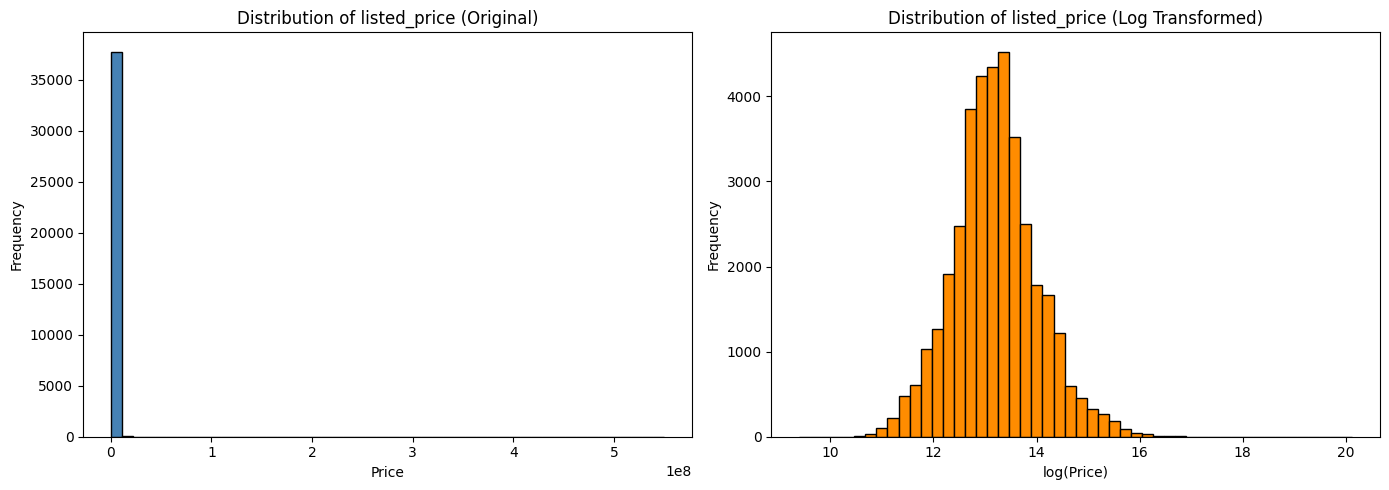

Plot saved.


In [6]:
# Cell 6 — Target Variable Analysis
print("=== listed_price Stats ===")
print(df['listed_price'].describe())

print(f"\nMin:  ₹{df['listed_price'].min():,.0f}")
print(f"Max:  ₹{df['listed_price'].max():,.0f}")
print(f"Mean: ₹{df['listed_price'].mean():,.0f}")
print(f"Median: ₹{df['listed_price'].median():,.0f}")

# Skewness
from scipy.stats import skew
print(f"\nSkewness: {skew(df['listed_price']):.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['listed_price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of listed_price (Original)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['listed_price']), bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Distribution of listed_price (Log Transformed)')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()
print("Plot saved.")

Rows before outlier removal: 37794
Rows after outlier removal: 37038

Price range after cleaning:
Min:  ₹84,678
Max:  ₹4,850,000
Mean: ₹722,471

Skewness after log transform: 0.1786


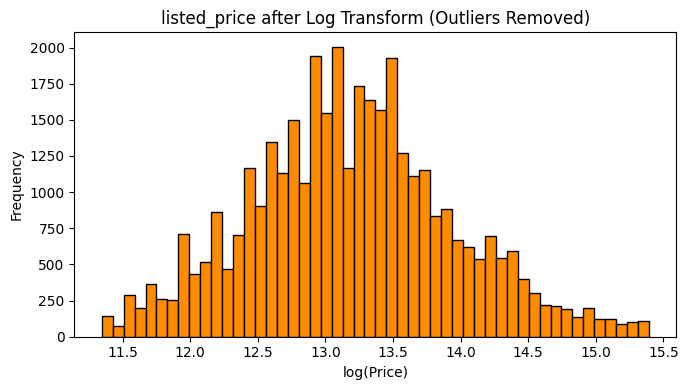

Shape now: (37038, 42)


In [7]:
# Cell 7 — Remove Outliers & Apply Log Transform to Target

print("Rows before outlier removal:", len(df))

# Remove extreme price outliers using IQR method
Q1 = df['listed_price'].quantile(0.01)
Q3 = df['listed_price'].quantile(0.99)
df = df[(df['listed_price'] >= Q1) & (df['listed_price'] <= Q3)]

print("Rows after outlier removal:", len(df))
print(f"\nPrice range after cleaning:")
print(f"Min:  ₹{df['listed_price'].min():,.0f}")
print(f"Max:  ₹{df['listed_price'].max():,.0f}")
print(f"Mean: ₹{df['listed_price'].mean():,.0f}")

# Apply log transform
df['listed_price'] = np.log1p(df['listed_price'])

from scipy.stats import skew
print(f"\nSkewness after log transform: {skew(df['listed_price']):.4f}")

# Plot final distribution
plt.figure(figsize=(7, 4))
plt.hist(df['listed_price'], bins=50, color='darkorange', edgecolor='black')
plt.title('listed_price after Log Transform (Outliers Removed)')
plt.xlabel('log(Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('target_clean.png', dpi=150)
plt.show()
print("Shape now:", df.shape)

Numerical columns: 20


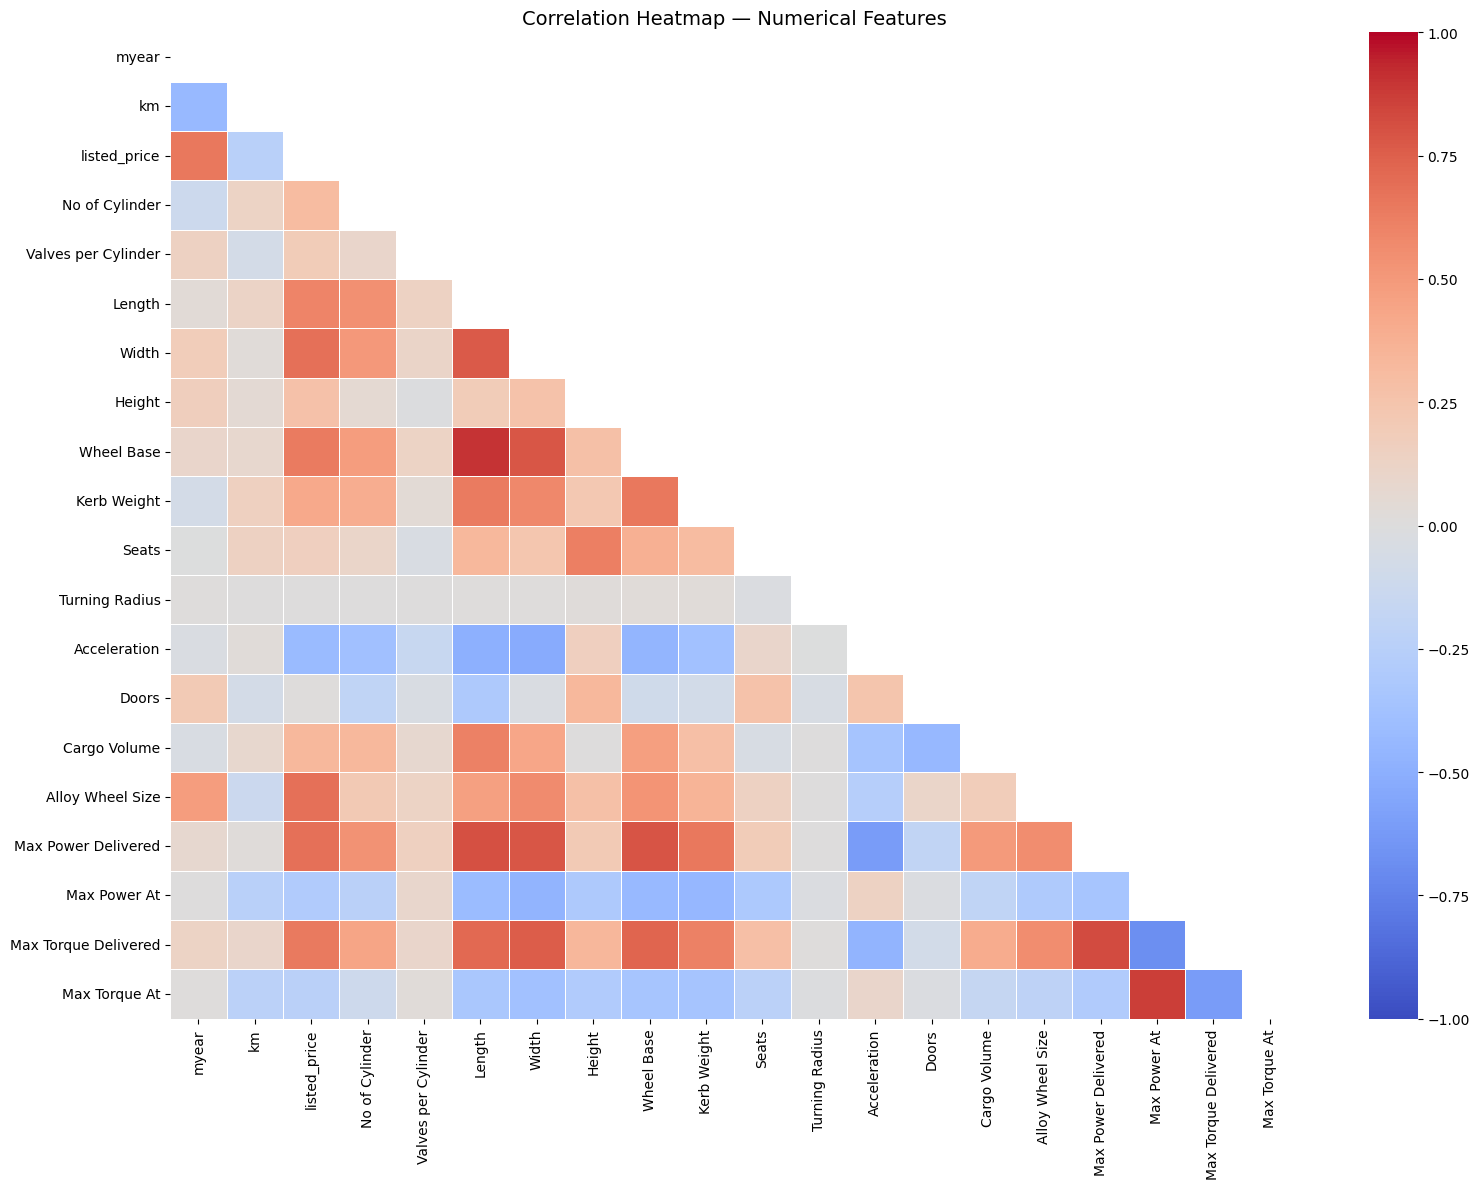


=== Top correlations with listed_price ===
Width                   0.687007
Alloy Wheel Size        0.686203
Max Power Delivered     0.684583
myear                   0.650719
Max Torque Delivered    0.641164
Wheel Base              0.639118
Length                  0.597745
Kerb Weight             0.421782
Cargo Volume            0.328897
No of Cylinder          0.308831
Height                  0.272606
Valves per Cylinder     0.194816
Seats                   0.160954
Doors                   0.013135
Turning Radius          0.005585
Max Torque At          -0.241452
km                     -0.249536
Max Power At           -0.291776
Acceleration           -0.429431


In [8]:
# Cell 8 — Correlation Heatmap

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", len(num_cols))

plt.figure(figsize=(16, 12))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Print top correlations with target
print("\n=== Top correlations with listed_price ===")
print(corr['listed_price'].drop('listed_price').sort_values(ascending=False).to_string())

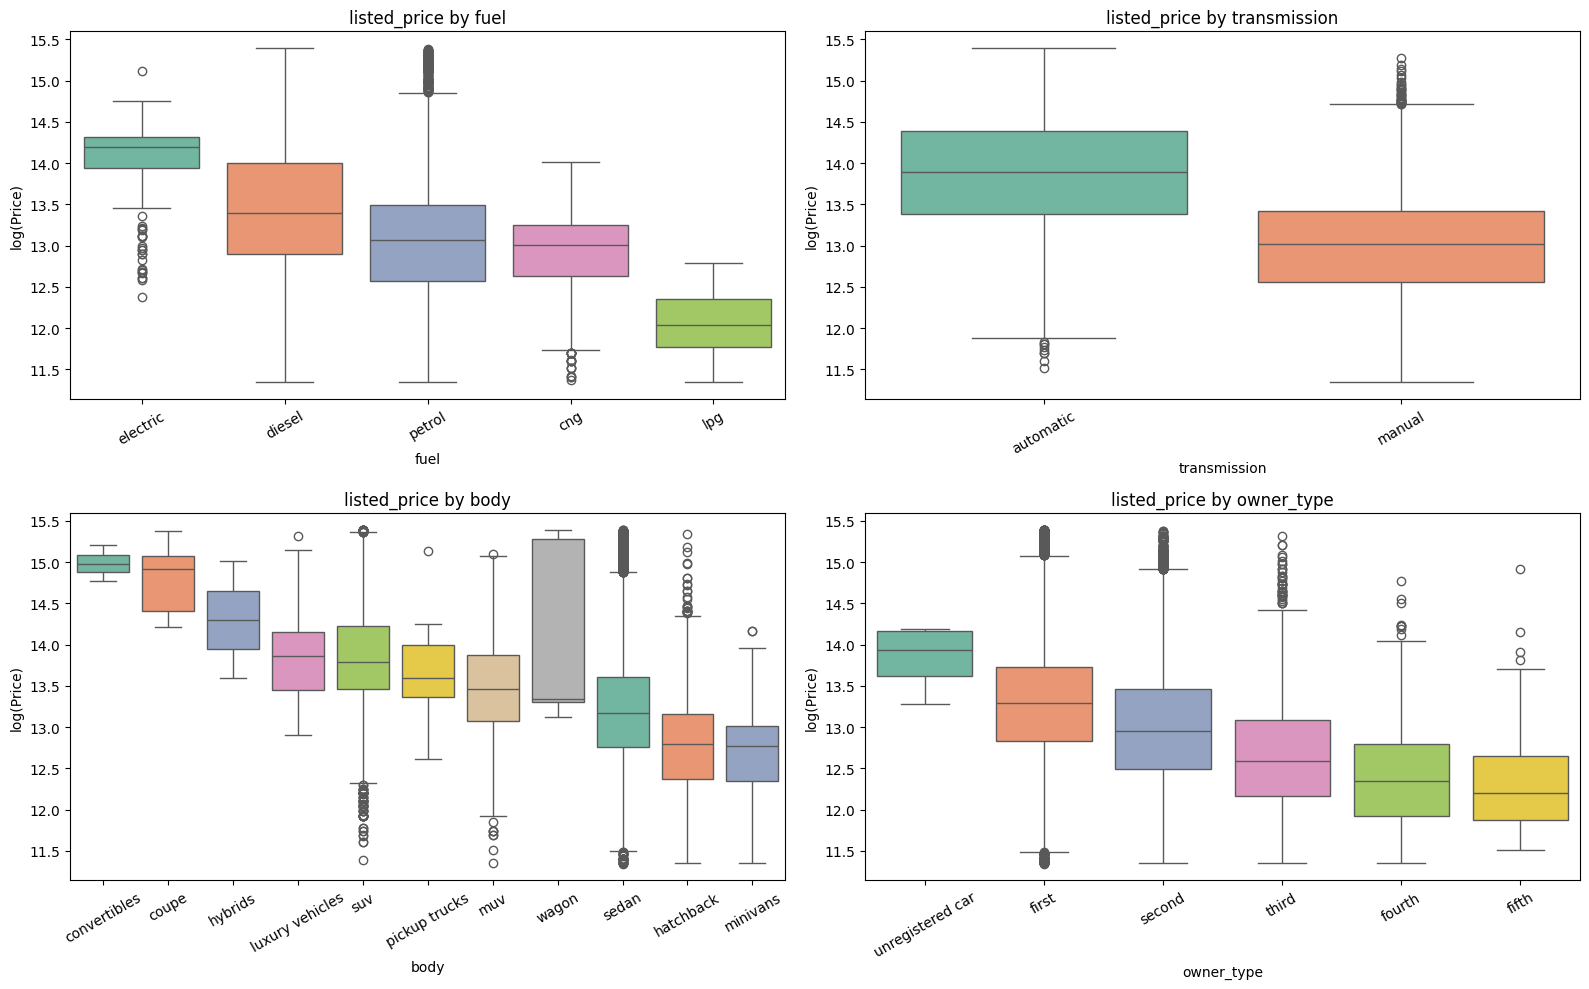

Plot saved.


In [9]:
# Cell 9 — Categorical Feature Analysis

cat_cols = ['fuel', 'transmission', 'body', 'owner_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['listed_price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='listed_price', order=order, ax=axes[i], palette='Set2')
    axes[i].set_title(f'listed_price by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(Price)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('categorical_boxplots.png', dpi=150)
plt.show()
print("Plot saved.")

In [10]:
# Cell 10 — Encode Categorical Columns

from sklearn.preprocessing import LabelEncoder

# Check all categorical columns remaining
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)
print("Count:", len(cat_cols))

le = LabelEncoder()
label_encoders = {}  # save encoders for use in Streamlit app later

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Save label encoders for Streamlit app
import pickle
os.makedirs('data', exist_ok=True)
with open('data/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("\nAll categorical columns encoded.")
print("Shape:", df.shape)
print("\nSample of encoded data:")
print(df.head(3))

Categorical columns to encode: ['body', 'transmission', 'fuel', 'oem', 'model', 'variant', 'City', 'Color', 'Engine Type', 'Valve Configuration', 'Gear Box', 'Drive Type', 'Steering Type', 'Front Brake Type', 'Rear Brake Type', 'Tyre Type', 'state', 'exterior_color', 'owner_type', 'Fuel Suppy System']
Count: 20

All categorical columns encoded.
Shape: (37038, 42)

Sample of encoded data:
   myear  body  transmission  fuel       km  oem  model  variant  City  \
0   2016     2             1     0  69162.0   25    204     2083   335   
1   2015     2             1     0  45864.0   25    179     1851   375   
2   2015     8             1     0  81506.0   12     74     2443   405   

   listed_price  ...  Cargo Volume  state  exterior_color  owner_type  \
0     12.821261  ...         180.0     30             608           1   
1     12.807655  ...         235.0     18             267           1   
2     12.950390  ...         400.0      8             608           3   

   Fuel Suppy Syste

In [11]:
# Cell 11 — Train-Test Split

X = df.drop(columns=['listed_price'])
y = df['listed_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

print(f"\nTraining samples:  {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Testing samples:   {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

X_train shape: (29630, 41)
X_test shape:  (7408, 41)
y_train shape: (29630,)
y_test shape:  (7408,)

Training samples:  29630 (80.0%)
Testing samples:   7408 (20.0%)


In [12]:
# Cell 12 — Scale Features & Save All Files to /data/

os.makedirs('data', exist_ok=True)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)

# Save numpy arrays
np.save('data/X_train.npy', X_train_scaled)
np.save('data/X_test.npy', X_test_scaled)
np.save('data/y_train.npy', y_train.values)
np.save('data/y_test.npy', y_test.values)

# Save scaler
with open('data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names (useful for Streamlit app)
with open('data/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

# Save label encoders (already saved in Cell 10 but re-save here to be safe)
with open('data/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Verify all files saved
print("\n=== Files saved in /data/ ===")
for f in os.listdir('data'):
    size = os.path.getsize(f'data/{f}') / 1024
    print(f"  {f} — {size:.1f} KB")

print("\n✅ EDA & Preprocessing complete!")
print(f"Final dataset: {len(df)} rows, {X.shape[1]} features")
print("Share the /data/ folder with Krishna and Pratik.")

Scaling done.
X_train_scaled shape: (29630, 41)
X_test_scaled shape:  (7408, 41)

=== Files saved in /data/ ===
  y_test.npy — 58.0 KB
  y_train.npy — 231.6 KB
  X_test.npy — 2373.0 KB
  label_encoders.pkl — 0.9 KB
  feature_names.pkl — 0.5 KB
  X_train.npy — 9491.0 KB
  scaler.pkl — 2.0 KB

✅ EDA & Preprocessing complete!
Final dataset: 37038 rows, 41 features
Share the /data/ folder with Krishna and Pratik.
